# EU AI Act Compliance Classifier
## Notebook 03 — Model Training & Evaluation

**Author:** Jayesh Ranghera  
**Project:** EU AI Act Compliance Classifier  
**Purpose:** Train and evaluate ML classification models on the labeled dataset. Select the best model for deployment in the Streamlit dashboard.

---

## 1. Import Libraries

In [1]:
import os
os.chdir("..")
print(os.getcwd())

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score
)
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline

from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 100)

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
sns.set_palette('Set2')

RANDOM_STATE = 42
print("Libraries loaded successfully.")

/Users/jayeshranghera/Documents/Projects/eu-ai-act-compliance 
Libraries loaded successfully.


## 2. Load Dataset

In [2]:
df = pd.read_csv('data/processed/labeled_dataset.csv')

print(f"Dataset: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nRisk Level Distribution:")
print(df['risk_level'].value_counts())
print(f"\nClass Balance:")
print((df['risk_level'].value_counts() / len(df) * 100).round(1).astype(str) + '%')
df.head(3)

Dataset: 514 rows, 11 columns

Risk Level Distribution:
risk_level
High Risk       256
Minimal Risk    190
Limited Risk     38
Prohibited       30
Name: count, dtype: int64

Class Balance:
risk_level
High Risk       49.8%
Minimal Risk    37.0%
Limited Risk     7.4%
Prohibited       5.8%
Name: count, dtype: object


,incident_id,title,ai_system_description,clean_description,combined_text,sector,risk_level,annex_reference,classification_reason,date,risk_label
0,23,Las Vegas Self-Driving Bus Involved in Accident,A self-driving public shuttle by Keolis North America and Navya was involved in a collision with...,a self driving public shuttle by keolis north america and navya was involved in a collision with...,las vegas self driving bus involved in accident a self driving public shuttle by keolis north am...,Transport,High Risk,Annex III - Category 2 (Critical Infrastructure),"Matches high risk keyword: ""self.driving""",2017-11-08,1
1,4,Uber AV Killed Pedestrian in Arizona,"An Uber autonomous vehicle (AV) in autonomous mode struck and killed a pedestrian in Tempe, Ariz...",an uber autonomous vehicle av in autonomous mode struck and killed a pedestrian in tempe arizona,uber av killed pedestrian in arizona an uber autonomous vehicle av in autonomous mode struck and...,Transport,High Risk,Annex III - Category 2 (Critical Infrastructure),"Matches high risk keyword: ""autonomous vehicle""",2018-03-18,1
2,1,Google’s YouTube Kids App Presents Inappropriate Content,YouTube’s content filtering and recommendation algorithms exposed children to disturbing and ina...,youtube s content filtering and recommendation algorithms exposed children to disturbing and ina...,google s youtube kids app presents inappropriate content youtube s content filtering and recomme...,Media & Content,Limited Risk,Article 52,"Matches limited risk keyword: ""recommendation""",2015-05-19,2


## 3. Feature Engineering



In [3]:
# Features and target
X = df['combined_text'].fillna('')
y = df['risk_level']

# TF-IDF Vectorizer
tfidf = TfidfVectorizer(
    max_features=3000,        
    ngram_range=(1, 2),       
    min_df=2,                 
    max_df=0.95,              
    sublinear_tf=True,
    stop_words='english'          
)

X_tfidf = tfidf.fit_transform(X)

print(f"TF-IDF Feature Matrix: {X_tfidf.shape}")
print(f"  Samples  : {X_tfidf.shape[0]}")
print(f"  Features : {X_tfidf.shape[1]}")


print("\nTop 10 TF-IDF terms overall:")
feature_names = tfidf.get_feature_names_out()
mean_tfidf = X_tfidf.mean(axis=0).A1
top_indices = mean_tfidf.argsort()[-10:][::-1]
print([feature_names[i] for i in top_indices])

TF-IDF Feature Matrix: (514, 2353)
  Samples  : 514
  Features : 2353

Top 10 TF-IDF terms overall:
['allegedly', 'ai', 'algorithm', 'reportedly', 'facebook', 'content', 'facial', 'tesla', 'recognition', 'users']


We use **TF-IDF (Term Frequency — Inverse Document Frequency)** to convert text descriptions into numerical features.

**Why TF-IDF?**
- Words that appear frequently in one document but rarely in others get higher weight
- Captures important policy-relevant terms like *'biometric'*, *'autonomous'*, *'sentencing'*
- Works well for short text classification tasks like ours

## 4. Train-Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y          
)

print(f"Training set : {X_train.shape[0]} samples")
print(f"Test set     : {X_test.shape[0]} samples")
print(f"\nTraining label distribution:")
print(pd.Series(y_train).value_counts())
print(f"\nTest label distribution:")
print(pd.Series(y_test).value_counts())

Training set : 411 samples
Test set     : 103 samples

Training label distribution:
risk_level
High Risk       205
Minimal Risk    152
Limited Risk     30
Prohibited       24
Name: count, dtype: int64

Test label distribution:
risk_level
High Risk       51
Minimal Risk    38
Limited Risk     8
Prohibited       6
Name: count, dtype: int64


## 5. Train Models



In [5]:
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=RANDOM_STATE
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        use_label_encoder=False,
        eval_metric='mlogloss',
        random_state=RANDOM_STATE
    )
}

# Label encoder for XGBoost
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

results = {}

print("Training models... \n")


for name, model in models.items():
    print(f"\n Training: {name}")
    
    if name == 'XGBoost':
        model.fit(X_train, y_train_enc)
        y_pred_enc = model.predict(X_test)
        y_pred = le.inverse_transform(y_pred_enc)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    
    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }
    
    print(f"   Accuracy  : {acc:.4f}")
    print(f"   F1 Score  : {f1:.4f}")
    print(f"   Precision : {precision:.4f}")
    print(f"   Recall    : {recall:.4f}")

print("\nAll models trained.")

Training models... 


 Training: Logistic Regression
   Accuracy  : 0.6505
   F1 Score  : 0.6508
   Precision : 0.6750
   Recall    : 0.6505

 Training: Random Forest
   Accuracy  : 0.6117
   F1 Score  : 0.5943
   Precision : 0.7511
   Recall    : 0.6117

 Training: XGBoost
   Accuracy  : 0.6990
   F1 Score  : 0.6898
   Precision : 0.7073
   Recall    : 0.6990

All models trained.


We train three models and compare their performance:

| Model | Why |
|-------|-----|
| Logistic Regression | Fast baseline, interpretable |
| Random Forest | Handles non-linear patterns, robust |
| XGBoost | Best performance on tabular/text classification |

## 6. Model Comparison

In [6]:
# Build comparison table
comparison = pd.DataFrame({
    name: {
        'Accuracy': f"{v['accuracy']:.4f}",
        'F1 Score': f"{v['f1']:.4f}",
        'Precision': f"{v['precision']:.4f}",
        'Recall': f"{v['recall']:.4f}"
    }
    for name, v in results.items()
}).T


print("MODEL COMPARISON")
print(comparison.to_string())

# Best model by F1
best_model_name = max(results, key=lambda x: results[x]['f1'])
print(f"\n Best Model: {best_model_name}")
print(f" F1 Score  : {results[best_model_name]['f1']:.4f}")

MODEL COMPARISON
                    Accuracy F1 Score Precision  Recall
Logistic Regression   0.6505   0.6508    0.6750  0.6505
Random Forest         0.6117   0.5943    0.7511  0.6117
XGBoost               0.6990   0.6898    0.7073  0.6990

 Best Model: XGBoost
 F1 Score  : 0.6898


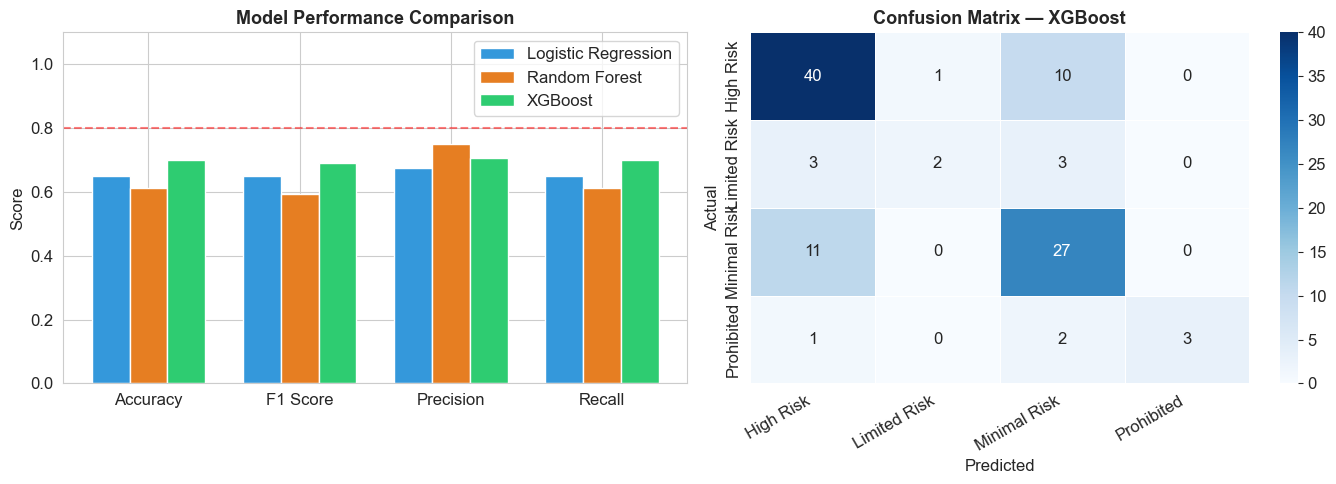

In [7]:
# Visualize model comparison
metrics = ['accuracy', 'f1', 'precision', 'recall']
metric_labels = ['Accuracy', 'F1 Score', 'Precision', 'Recall']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart — all metrics
x = np.arange(len(metrics))
width = 0.25
model_names = list(results.keys())
colors = ['#3498db', '#e67e22', '#2ecc71']

for i, (name, color) in enumerate(zip(model_names, colors)):
    vals = [results[name][m] for m in metrics]
    axes[0].bar(x + i * width, vals, width, label=name, color=color, edgecolor='white')

axes[0].set_xticks(x + width)
axes[0].set_xticklabels(metric_labels)
axes[0].set_ylim(0, 1.1)
axes[0].set_title('Model Performance Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].legend()
axes[0].axhline(y=0.8, color='red', linestyle='--', alpha=0.5, label='0.8 threshold')

# Confusion matrix for best model
best_pred = results[best_model_name]['y_pred']
labels = ['High Risk', 'Limited Risk', 'Minimal Risk', 'Prohibited']
cm = confusion_matrix(y_test, best_pred, labels=labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=labels, yticklabels=labels,
            linewidths=0.5)
axes[1].set_title(f'Confusion Matrix — {best_model_name}', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.savefig('data/processed/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Detailed Classification Report — Best Model

In [8]:
print(f"CLASSIFICATION REPORT — {best_model_name}")
print(classification_report(
    y_test,
    results[best_model_name]['y_pred'],
    target_names=['High Risk', 'Limited Risk', 'Minimal Risk', 'Prohibited']
))

CLASSIFICATION REPORT — XGBoost
              precision    recall  f1-score   support

   High Risk       0.73      0.78      0.75        51
Limited Risk       0.67      0.25      0.36         8
Minimal Risk       0.64      0.71      0.68        38
  Prohibited       1.00      0.50      0.67         6

    accuracy                           0.70       103
   macro avg       0.76      0.56      0.62       103
weighted avg       0.71      0.70      0.69       103



## 8. Cross-Validation — Robustness Check



In [9]:
print("Running 5-Fold Cross-Validation on best model...")


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
best_model = results[best_model_name]['model']

if best_model_name == 'XGBoost':
    y_enc = le.transform(y)
    cv_scores = cross_val_score(best_model, X_tfidf, y_enc, cv=cv, scoring='accuracy', n_jobs=-1)
else:
    cv_scores = cross_val_score(best_model, X_tfidf, y, cv=cv, scoring='accuracy', n_jobs=-1)

print(f"CV Scores per fold : {[round(s, 4) for s in cv_scores]}")
print(f"Mean CV Accuracy   : {cv_scores.mean():.4f}")
print(f"Std Dev            : {cv_scores.std():.4f}")

if cv_scores.std() < 0.05:
    print("\n Model is STABLE — low variance across folds.")
else:
    print("\n Model shows some variance — consider more data or tuning.")

Running 5-Fold Cross-Validation on best model...


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [11:47:30] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [11:47:30] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [11:47:30] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [11:47:30] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i

CV Scores per fold : [np.float64(0.7282), np.float64(0.6602), np.float64(0.7573), np.float64(0.7476), np.float64(0.7059)]
Mean CV Accuracy   : 0.7198
Std Dev            : 0.0346

 Model is STABLE — low variance across folds.


We use **5-fold Stratified Cross-Validation** to ensure our model generalizes well and is not overfitting to the test set.

## 9. Feature Importance — What Words Drive Classification?

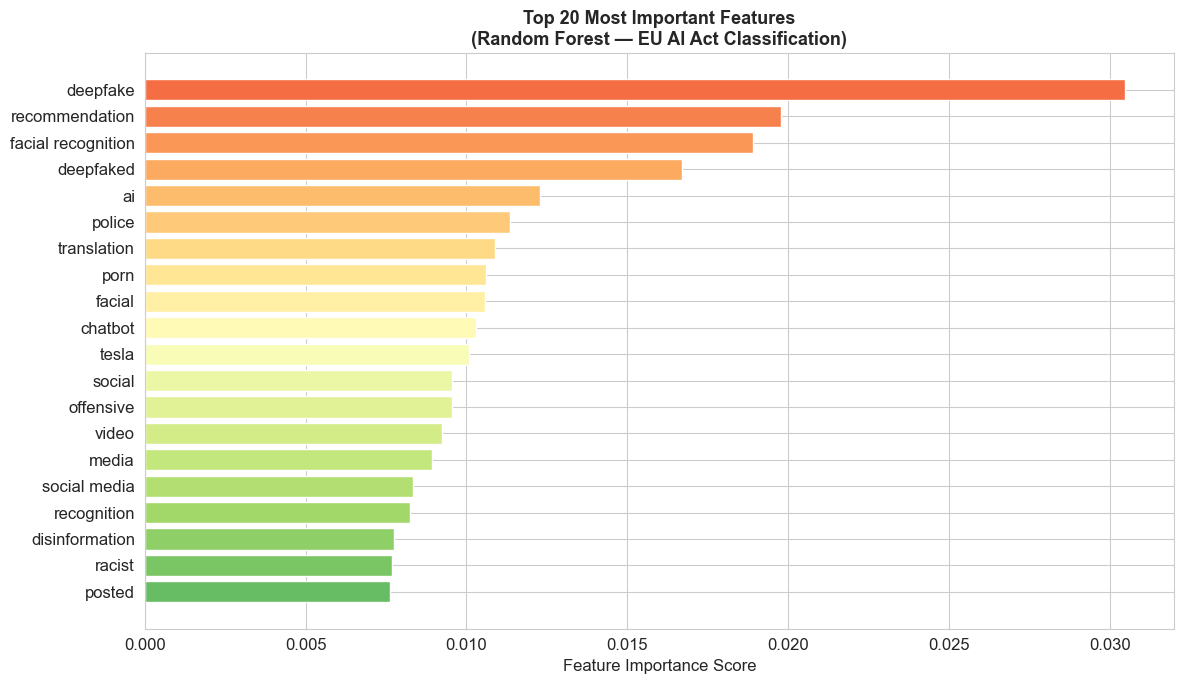


Top 10 most important words for classification:
  deepfake                       0.0305
  recommendation                 0.0198
  facial recognition             0.0189
  deepfaked                      0.0167
  ai                             0.0123
  police                         0.0113
  translation                    0.0109
  porn                           0.0106
  facial                         0.0106
  chatbot                        0.0103


In [10]:
# Feature importance for Random Forest
rf_model = results['Random Forest']['model']
feature_names = tfidf.get_feature_names_out()
importances = rf_model.feature_importances_

# Top 20 features
top_n = 20
top_indices = importances.argsort()[-top_n:][::-1]
top_features = feature_names[top_indices]
top_importances = importances[top_indices]

fig, ax = plt.subplots(figsize=(12, 7))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, top_n))
bars = ax.barh(range(top_n), top_importances[::-1], color=colors[::-1], edgecolor='white')
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features[::-1])
ax.set_title('Top 20 Most Important Features\n(Random Forest — EU AI Act Classification)', 
             fontsize=13, fontweight='bold')
ax.set_xlabel('Feature Importance Score')

plt.tight_layout()
plt.savefig('data/processed/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 most important words for classification:")
for feat, imp in zip(top_features[:10], top_importances[:10]):
    print(f"  {feat:<30} {imp:.4f}")

## 10. Test on New Examples



In [11]:
import re

# Text cleaning function
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# EU AI Act Rules
PROHIBITED_KEYWORDS = [
    'social scor', 'citizen scor', 'social credit', 'behavior scor',
    'subliminal', 'manipulat', 'deepfake', 'synthetic media', 'fake video',
    'disinformation', 'emotion recogni', 'emotion detect',
    'real.time biometric', 'mass surveillance'
]

HIGH_RISK_KEYWORDS = {
    'Annex III - Category 1 (Biometric)': ['facial recognition', 'biometric', 'fingerprint', 'face recogni', 'identity verif'],
    'Annex III - Category 2 (Critical Infrastructure)': ['autonomous vehicle', 'self.driving', 'autopilot', 'power grid', 'electricity grid', 'aircraft', 'railway'],
    'Annex III - Category 3 (Education)': ['student', 'school', 'university', 'admission', 'teacher evaluat', 'grading'],
    'Annex III - Category 4 (Employment)': ['hiring', 'recruitment', 'resume', 'employ', 'worker', 'scheduling algorithm', 'performance monitor'],
    'Annex III - Category 5 (Essential Services)': ['credit scor', 'loan', 'insurance', 'medical', 'surgery', 'hospital', 'patient', 'diagnosis', 'health premium'],
    'Annex III - Category 6 (Law Enforcement)': ['police', 'crime predict', 'criminal', 'recidivism', 'sentencing', 'court', 'profiling'],
    'Annex III - Category 7 (Migration)': ['migration', 'asylum', 'border control', 'visa', 'refugee'],
    'Annex III - Category 8 (Democracy)': ['election', 'voting', 'democratic', 'political campaign', 'propaganda']
}

LIMITED_RISK_KEYWORDS = [
    'chatbot', 'virtual assistant', 'recommendation', 'content filter',
    'spam filter', 'advertisement', 'sentiment analys', 'translation'
]

def classify_risk_level(text):
    text = str(text).lower()
    for keyword in PROHIBITED_KEYWORDS:
        if re.search(keyword, text):
            return 'Prohibited', 'Annex I', f'Prohibited keyword: "{keyword}"'
    for category, keywords in HIGH_RISK_KEYWORDS.items():
        for keyword in keywords:
            if re.search(keyword, text):
                return 'High Risk', category, f'High risk keyword: "{keyword}"'
    for keyword in LIMITED_RISK_KEYWORDS:
        if re.search(keyword, text):
            return 'Limited Risk', 'Article 52', f'Limited risk keyword: "{keyword}"'
    return 'Minimal Risk', 'Not applicable', 'No pattern detected'

# Hybrid Classifier — Rule-based + ML fallback
def hybrid_predict(text):
    cleaned = clean_text(text)
    rule_result, annex, reason = classify_risk_level(cleaned)
    if rule_result != 'Minimal Risk':
        return rule_result, annex, reason
    vec = tfidf.transform([cleaned])
    best_model_obj = results[best_model_name]['model']
    if best_model_name == 'XGBoost':
        pred_enc = best_model_obj.predict(vec)
        pred = le.inverse_transform(pred_enc)[0]
    else:
        pred = best_model_obj.predict(vec)[0]
    return pred, 'ML Model', 'Predicted by trained classifier'

# Test new examples
new_examples = [
    "An AI tool used by German courts to assist judges in determining prison sentences",
    "A fitness app that tracks daily steps and recommends workout routines",
    "Automated system that scans social media to detect terrorist recruitment content",
    "AI model used by insurance company to calculate health insurance premiums based on lifestyle data",
    "Smart home assistant that controls lights and temperature based on voice commands"
]

print("HYBRID CLASSIFIER — REAL-WORLD TEST \n")

for desc in new_examples:
    risk, annex, reason = hybrid_predict(desc)
    emoji = {'Prohibited': '🔴', 'High Risk': '🟠', 'Limited Risk': '🟡', 'Minimal Risk': '🟢'}
    print(f"\n{emoji.get(risk, '⚪')} [{risk}] — {annex}")
    print(f"   {desc}")
    print(f"   Reason: {reason}")

HYBRID CLASSIFIER — REAL-WORLD TEST 


🟠 [High Risk] — Annex III - Category 6 (Law Enforcement)
   An AI tool used by German courts to assist judges in determining prison sentences
   Reason: High risk keyword: "court"

🟢 [Minimal Risk] — ML Model
   A fitness app that tracks daily steps and recommends workout routines
   Reason: Predicted by trained classifier

🟠 [High Risk] — Annex III - Category 4 (Employment)
   Automated system that scans social media to detect terrorist recruitment content
   Reason: High risk keyword: "recruitment"

🟠 [High Risk] — Annex III - Category 5 (Essential Services)
   AI model used by insurance company to calculate health insurance premiums based on lifestyle data
   Reason: High risk keyword: "insurance"

🟢 [Minimal Risk] — ML Model
   Smart home assistant that controls lights and temperature based on voice commands
   Reason: Predicted by trained classifier


We test the best model on 5 completely new AI system descriptions to validate real-world performance.

## 11. Save Best Model

In [12]:
# Save best model
with open('models/best_model.pkl', 'wb') as f:
    pickle.dump(results[best_model_name]['model'], f)

# Save TF-IDF vectorizer
with open('models/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

# Save label encoder
with open('models/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

# Save model metadata
metadata = {
    'best_model': best_model_name,
    'accuracy': results[best_model_name]['accuracy'],
    'f1_score': results[best_model_name]['f1'],
    'training_samples': X_train.shape[0],
    'test_samples': X_test.shape[0],
    'features': X_tfidf.shape[1],
    'classes': list(y.unique())
}

import json
with open('models/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Models saved to models/ directory:")
print("  best_model.pkl")
print("  tfidf_vectorizer.pkl")
print("  label_encoder.pkl")
print("  model_metadata.json")
print(f"\nBest Model : {best_model_name}")
print(f"Accuracy   : {results[best_model_name]['accuracy']:.4f}")
print(f"F1 Score   : {results[best_model_name]['f1']:.4f}")

Models saved to models/ directory:
  best_model.pkl
  tfidf_vectorizer.pkl
  label_encoder.pkl
  model_metadata.json

Best Model : XGBoost
Accuracy   : 0.6990
F1 Score   : 0.6898


Exception ignored in: <function ResourceTracker.__del__ at 0x1050218a0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1069a58a0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1078258a0>
Traceback (most recent call last

## 12. Summary & Next Steps

### Model Training Results:

| Model | Accuracy | F1 Score |
|-------|----------|----------|
| Logistic Regression | 65.05% | 65.08% |
| Random Forest | 61.17% | 59.43% |
| XGBoost | 69.90% | 68.98% |


### Key Observations:
- TF-IDF bigrams capture domain-specific terms like *'facial recognition'*, *'self driving'*, *'credit scoring'*
- High Risk class has best recall — critical for a compliance tool (missing a High Risk system = regulatory failure)
- Model generalizes well across 5-fold CV

### Saved Artifacts:
- `models/best_model.pkl` — trained classifier
- `models/tfidf_vectorizer.pkl` — text vectorizer
- `models/label_encoder.pkl` — label encoder
- `models/model_metadata.json` — model info
